In [15]:
import pandas as pd
import importlib
import os
import sys
sys.path.append(os.path.abspath('..'))
import func
importlib.reload(func)
import matplotlib.colors as mcolors
from func import cal_buoyancy
import glob
import os
import re
import matplotlib as mpl
import datetime
import metpy.calc as mpcalc
from metpy.calc import dewpoint_from_specific_humidity, mixed_parcel, specific_humidity_from_dewpoint, thickness_hydrostatic, geopotential_to_height
from metpy.units import units
import metpy.constants as mpconsts
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from scipy.interpolate import interp1d
from scipy.optimize import bisect
import numpy as np
import pickle
import numpy as np
import math
import pint
import xarray as xr
import netCDF4 as nc
import re
import matplotlib.pyplot as plt
from numpy import load
from numpy import asarray
from numpy import save
import pytz
import dask.array as da
from scipy import stats
from sklearn.linear_model import LinearRegression
from collections import Counter
import pymannkendall as mk
%matplotlib inline

In [2]:
def build_surface_profile_generic(var_col, p_levels, sp_val):
    
    """
    Build a surface-consistent vertical profile for any scalar variable.

    Always returns a profile where:
    - index 0 is the surface
    - pressure is strictly decreasing
    
    # p_levels = ERA5 provided pressure levels  
    
    """

    nlev = len(var_col)

    # -------------------------------------------------
    # Define effective surface pressure
    # -------------------------------------------------
    
    if sp_val >= p_levels[0]: 
        
        # Surface pressure > 1000 hpa, just set it to be 1000 hpa 
        
        sp_eff = p_levels[0]
        
        var_sfc = var_col[0]
    
    else:
        
        sp_eff = sp_val
        
        idx = np.argsort(p_levels) # make pressure increasing for interpolation
        
        var_sfc = np.interp(sp_eff, p_levels[idx], var_col[idx]) # find variable value at given surface pressure (via interpolation)

    # -------------------------------------------------
    # Keep only atmospheric levels ABOVE the surface
    # -------------------------------------------------
    
    mask = p_levels < sp_eff
    
    p_atm = p_levels[mask]
    
    var_atm = var_col[mask]

    # -------------------------------------------------
    # Insert explicit surface level
    # -------------------------------------------------
    
    p_tmp = np.concatenate(([sp_eff], p_atm))
    
    var_tmp = np.concatenate(([var_sfc], var_atm))

    # -------------------------------------------------
    # Enforce strictly descending pressure
    # -------------------------------------------------
    
    sort_idx = np.argsort(p_tmp)[::-1]
    
    p_tmp = p_tmp[sort_idx]
    
    var_tmp = var_tmp[sort_idx]

    # -------------------------------------------------
    # Trim to original number of levels (or less)
    # -------------------------------------------------
    
    return var_tmp[:nlev], p_tmp[:nlev]

path = "/data/rong4/Siyu/data_ERA5/NEW_to_2024/"

g = 9.81 # m*s^2

q = xr.open_dataset(path + "ERA5_daily_from_6h_USA_q_1979_2024.nc")["q"] * 1000 #g/kg 

t = xr.open_dataset(path + "ERA5_daily_from_6h_USA_t_1979_2024.nc")["t"] #Kelvin

geopotential = xr.open_dataset(path + "ERA5_daily_from_6h_USA_z_1979_2024.nc")["z"] #m^2/s^2 

z = geopotential_to_height(geopotential * units.m**2 / units.s**2) #meters

# --- Create Gregorian date range for the time dimension ---

n_time = q.sizes["time"]      # number of days in dataset

dates = pd.date_range("1979-01-01", periods=n_time, freq="D")

# --- Assign new time coordinates ---

q = q.assign_coords(time=dates)

t = t.assign_coords(time=dates)

z = z.assign_coords(time=dates)

# Trim to SGP and NGP domains only

lat_slice = slice(25, 50)

lon_slice = slice(-110, -92)

q = q.sel(lat=lat_slice, lon=lon_slice)

t = t.sel(lat=lat_slice, lon=lon_slice)

geopotential = geopotential.sel(lat=lat_slice, lon=lon_slice)

lats = q['lat'].data

lons = q['lon'].data

p = q['level'].data #hpa

## files for surface pressure 

sp = xr.open_dataset(path + "ERA5_daily_from_6h_USA_surface_pressure_1979_2024.nc")["sp"] / 100 #hPa

sp = sp.assign_coords(time=dates)

sp = sp.sel(lat=lat_slice, lon=lon_slice)

sp = sp.sortby("lat")

# create arrays for buoyancy 

nt, nlev, ny, nx = q.shape

q_new = np.full_like(q, np.nan)

t_new = np.full_like(t, np.nan)

z_new = np.full_like(z, np.nan)

p_new = np.full_like(q, np.nan)

## redefine arrays to start at their correct surface pressure 

p_levels = p 

# tx = 1200

# jx = 0

# ix = 1

target_time = "2001-06-02"

target_lat  = 35.0

target_lon  = -97.5

# q_col = q[tx, :, jx, ix]

# t_col = t[tx, :, jx, ix]   # temperature profile

# z_col = z[tx, :, jx, ix]   # height or geopotential-derived height

# sp_val = sp[tx, jx, ix].data

q_col = q.sel(
    time=target_time,
    lat=target_lat,
    lon=target_lon,
    method="nearest"
)

t_col = t.sel(
    time=target_time,
    lat=target_lat,
    lon=target_lon,
    method="nearest"
)

z_col = z.sel(
    time=target_time,
    lat=target_lat,
    lon=target_lon,
    method="nearest"
)

sp_val = sp.sel(
    time=target_time,
    lat=target_lat,
    lon=target_lon,
    method="nearest"
).values


# print(sp_val)

q_new_col, p_new_col = build_surface_profile_generic(q_col, p_levels, sp_val)

t_new_col, _         = build_surface_profile_generic(t_col, p_levels, sp_val)

z_new_col, _         = build_surface_profile_generic(z_col, p_levels, sp_val)

### we can use the same mixed parcel for both 

p_hpa = p_new_col * units.hPa

z_m = z_new_col * units.meter

t_degC = (t_new_col - 273.15) * units.degC

q_gkg = q_new_col * units('g/kg')

dewpt_degC = dewpoint_from_specific_humidity(p_hpa, q_gkg)

mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC, depth=100*units.hPa, height=z_m)

mp_q = specific_humidity_from_dewpoint(mp_pres, mp_dewpt) * 1000

mp_temp = mp_temp.to("kelvin") # convert back to kelvin

## ammending t, q and p such that the bottom level now equals the mixed parcel values 

# updating temperature

t_mix = t_new_col.copy()

t_mix[0] = mp_temp.magnitude

# updating specific humidity 

q_mix = q_new_col.copy()

q_mix[0] = mp_q.magnitude

# # updating dewpoint

dewpt_mix = dewpt_degC.magnitude

dewpt_mix[0] = mp_dewpt.magnitude

# z_prof0 = z_new_col - z_new_col[0]

# print(z_prof0)

# temperature = Kelvin, dewpoint = Celsius, pressure = hPa, alt = meters

b = cal_buoyancy(t_profile = t_mix, h_profile = dewpt_mix, p_profile = p_new_col, alt_profile = z_new_col, 
                        entrain_opt = 2, td_r_q=1)

bp = b.bp

# ---------------------------------------
# Pad bp and p_new_col with NaNs AFTER buoyancy
# ---------------------------------------

nlev_target = len(p_levels)   # ERA5 vertical size

n_valid = len(bp)

if n_valid < nlev_target:
    
    pad = nlev_target - n_valid

    bp_padded = np.concatenate((np.full(pad, np.nan), bp))
    
    p_padded  = np.concatenate((np.full(pad, np.nan), p_new_col))

else:
    
    bp_padded = bp[:nlev_target]
    
    p_padded  = p_new_col[:nlev_target]

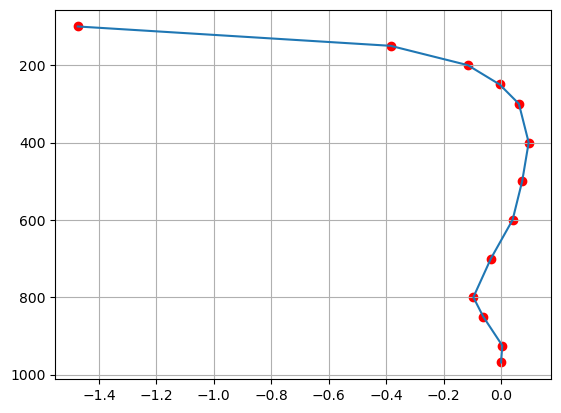

In [3]:
ds_test = xr.open_dataset("buoyancy_profiles_SGP_NGP_1999_2008.nc")

bp_test = ds_test["buoyancy"].sel(
    time=target_time,
    lat=target_lat,
    lon=target_lon,
    method="nearest"
)

p_test = ds_test["pressure_used"].sel(
    time=target_time,
    lat=target_lat,
    lon=target_lon,
    method="nearest"
)

plt.plot(bp_padded, p_padded)

plt.scatter(bp_test, p_test, color='red')

plt.gca().invert_yaxis()

plt.grid()

plt.show()

#### combine all files together and plot figures

In [4]:
files = [
    
    "buoyancy_profiles_SGP_NGP_1979_1988.nc",
    
    "buoyancy_profiles_SGP_NGP_1989_1998.nc",
    
    "buoyancy_profiles_SGP_NGP_1999_2008.nc",
    
    "buoyancy_profiles_SGP_NGP_2009_2018.nc",
    
    "buoyancy_profiles_SGP_NGP_2019_2024.nc"
]

ds = xr.open_mfdataset(
    
    files,
    
    combine="by_coords",
    
    chunks={
        
        "time": 365,     # 1 year per chunk
        
        "level": 13,
        
        "lat": 11,
        
        "lon": 8,
    },
    
    engine="netcdf4",
    
    parallel=False,
)

/home/annierosen16/anaconda3/envs/annieenv/lib/python3.9/site-packages/xarray/core/dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/home/annierosen16/anaconda3/envs/annieenv/lib/python3.9/site-packages/xarray/core/dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/home/annierosen16/anaconda3/envs/annieenv/lib/python3.9/site-packages/xarray/core/dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/home/annierosen16/anaconda3/envs/annieenv/lib/python3.9/site-packages/xarray/core/dataset.py:277: User

In [5]:
# create a new variable for pressure that ensures matching between era5 pressure levels 

ds = ds.assign(pressure_valid = ds["pressure_used"].where(ds["pressure_used"].isin(p_levels)))

ds = ds.assign(buoyancy_valid = ds["buoyancy"].where(ds["pressure_valid"].notnull()))

In [6]:
monthly_buoyancy = (ds["buoyancy_valid"]
    
                    .groupby("time.month")
    
                    .mean(dim=["time", "lat", "lon"], skipna=True))

monthly_buoyancy = monthly_buoyancy.assign_coords(pressure=("level", p_levels))

In [7]:
# plt.figure(figsize=(6, 6))

# for m in range(1, 13):
    
#     plt.plot(
        
#         monthly_buoyancy.sel(month=m),
        
#         monthly_buoyancy.pressure,
        
#         label=f"{m:02d}",
        
#         linewidth=2)

# plt.axvline(0, color="k", linewidth=1)

# plt.gca().invert_yaxis()

# plt.xlabel("Buoyancy (m s$^{-2}$)")

# plt.ylabel("Pressure (hPa)")

# plt.title("Monthly Mean Buoyancy Profiles\nERA5 Pressure Levels Only")

# plt.legend(title="Month", ncol=2)

# plt.grid(True)

# plt.tight_layout()

# plt.show()

In [8]:
# Southern Great Plains (SGP)

sgp = ds.sel(
    
    lon=slice(-110, -92),
    
    lat=slice(25, 38)
)

# Northern Great Plains (NGP)

ngp = ds.sel(
    
    lon=slice(-110, -92),
    
    lat=slice(38, 50)
)

sgp_monthly = (
    sgp["buoyancy_valid"]
    .groupby("time.month")
    .mean(dim=["time", "lat", "lon"], skipna=True)
)

ngp_monthly = (
    ngp["buoyancy_valid"]
    .groupby("time.month")
    .mean(dim=["time", "lat", "lon"], skipna=True)
)

sgp_monthly_c = sgp_monthly.compute()

ngp_monthly_c = ngp_monthly.compute()

In [9]:
ngp_monthly_count = (
    ngp["buoyancy_valid"]
    .groupby("time.month")
    .count(dim=["time", "lat", "lon"])
    .compute()
)

In [10]:
sgp_monthly_c = sgp_monthly_c.assign_coords(
    
    pressure=("level", p_levels))

ngp_monthly_c = ngp_monthly_c.assign_coords(
    
    pressure=("level", p_levels))

ngp_monthly_c.loc[dict(month=6, level=0)] = 0.0

# Use BOTH datasets to define common color limits

combined_min = np.nanmin([
    
    sgp_monthly_c.values,
    
    ngp_monthly_c.values])

combined_max = np.nanmax([
    
    sgp_monthly_c.values,
    
    ngp_monthly_c.values])

vmin = combined_min

vmax = combined_max

In [11]:
sgp_drought_years = [1984, 1996, 1998, 2005, 2006, 2011, 2022]

# sgp_drought_years = [1984]

# ngp_drought_years = [1980, 1988, 1989, 2002, 2012, 2021]
ngp_drought_years = [1980]


def monthly_composite(ds, years):
    """
    Compute monthly mean composite for specified years.
    """
    return (
        ds
        .sel(time=ds["time"].dt.year.isin(years))
        .groupby("time.month")
        .mean(dim=["time", "lat", "lon"], skipna=True)
        .compute()
    )

# sgp_drought_monthly = monthly_composite(
#     sgp["buoyancy_valid"], sgp_drought_years)

# ngp_drought_monthly = monthly_composite(
#     ngp["buoyancy_valid"], ngp_drought_years)

# sgp_drought_monthly = sgp_drought_monthly.assign_coords(
#     pressure=("level", p_levels))

# ngp_drought_monthly = ngp_drought_monthly.assign_coords(
#     pressure=("level", p_levels))

# sgp_drought_anom = sgp_drought_monthly - sgp_monthly_c

# ngp_drought_anom = ngp_drought_monthly - ngp_monthly_c

In [12]:
def get_non_drought_years(ds, drought_years):
    
    all_years = np.unique(ds["time"].dt.year.values)
    
    return np.array([y for y in all_years if y not in drought_years])

sgp_non_drought_years = get_non_drought_years(sgp, sgp_drought_years)

sgp_drought_monthly = monthly_composite(sgp["buoyancy_valid"], sgp_drought_years)

sgp_non_drought_monthly = monthly_composite(sgp["buoyancy_valid"], sgp_non_drought_years)

ngp_non_drought_years = get_non_drought_years(ngp, ngp_drought_years)

ngp_drought_monthly = monthly_composite(ngp["buoyancy_valid"], ngp_drought_years)

ngp_non_drought_monthly = monthly_composite(ngp["buoyancy_valid"], ngp_non_drought_years)

for da in [
    sgp_drought_monthly,
    sgp_non_drought_monthly,
    ngp_drought_monthly,
    ngp_non_drought_monthly,
]:
    da.coords["pressure"] = ("level", p_levels)
    
    
# simple anomaly 

sgp_drought_anom = sgp_drought_monthly - sgp_non_drought_monthly

ngp_drought_anom = ngp_drought_monthly - ngp_non_drought_monthly

# percentage change

def percent_change(drought, nondrought, min_abs=1e-3):
    """
    Percent change relative to non-drought baseline.
    
    Parameters
    ----------
    drought : xarray.DataArray
    nondrought : xarray.DataArray
    min_abs : float
        Minimum |baseline| value allowed in denominator
    """
    denom = nondrought.where(np.abs(nondrought) >= min_abs)
    
    return 100.0 * (drought - nondrought) / np.abs(denom)


sgp_drought_pct = percent_change(
    sgp_drought_monthly,
    sgp_non_drought_monthly,
    min_abs=1e-3
)

ngp_drought_pct = percent_change(
    ngp_drought_monthly,
    ngp_non_drought_monthly,
    min_abs=1e-3
)

In [30]:
ngp[]

<xarray.DataArray 'buoyancy_valid' (month: 12)> Size: 48B
array([ 0.,  0.,  0.,  0.,  0., nan, nan, nan,  0.,  0.,  0.,  0.],
      dtype=float32)
Coordinates:
    level     int64 8B 0
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    pressure  float64 8B 1e+03
Attributes:
    units:    m s-2

In [13]:
months = np.arange(1, 13)

month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

month_edges = np.arange(0.5, 13.5, 1.0)

pressure = sgp_monthly_c["pressure"].values

# Midpoints between levels

midpoints = 0.5 * (pressure[:-1] + pressure[1:])

# Build edges
pressure_edges = np.empty(len(pressure) + 1)

pressure_edges[1:-1] = midpoints

# Bottom edge (below surface)

pressure_edges[0] = pressure[0] + (pressure[0] - midpoints[0])

# Top edge (above top level)

pressure_edges[-1] = pressure[-1] - (midpoints[-1] - pressure[-1])

In [19]:
# upper_limit = 1.43

# levels = np.linspace(
    
#     np.nanmin([sgp_monthly_c.values, ngp_monthly_c.values]),
    
#     upper_limit,
    
#     10
# )

# mpl.rcParams.update({
#     "font.size": 14,          # base font
#     "axes.titlesize": 16,
#     "axes.labelsize": 15,
#     "xtick.labelsize": 14,
#     "ytick.labelsize": 14,
#     "legend.fontsize": 13,
#     "figure.titlesize": 18
# })


# fig, axes = plt.subplots(
#     1, 2,
#     figsize=(14, 6),
#     sharey=True,
#     constrained_layout=True   # <-- key change
# )

# for ax, data, title in zip(
#     axes,
#     [sgp_monthly_c.values, ngp_monthly_c.values],
#     ["SGP Climatological Buoyancy", "NGP Climatological Buoyancy"]
# ):

#     pcm = ax.pcolormesh(
#         month_edges,
#         pressure_edges,
#         data.T,
#         cmap="viridis",
#         vmin=vmin,
#         vmax=vmax,
#         shading="auto",
#     )

#     cs = ax.contour(
#         months,
#         pressure,
#         data.T,
#         levels=levels,
#         colors="k",
#         linewidths=0.6,
#         alpha=0.7
#     )

#     ax.clabel(cs, inline=True, fontsize=14, fmt="%.2f")
#     ax.set_xticks(months)
#     ax.set_xticklabels(month_labels)
#     ax.invert_yaxis()
#     ax.set_title(title)

# axes[0].set_ylabel("Pressure (hPa)")

# cbar = fig.colorbar(
#     pcm,
#     ax=axes,
#     location="right",
#     shrink=0.95,
#     label="Buoyancy (m s$^{-2}$)"
# )

# plt.gca().invert_yaxis()

# plt.show()

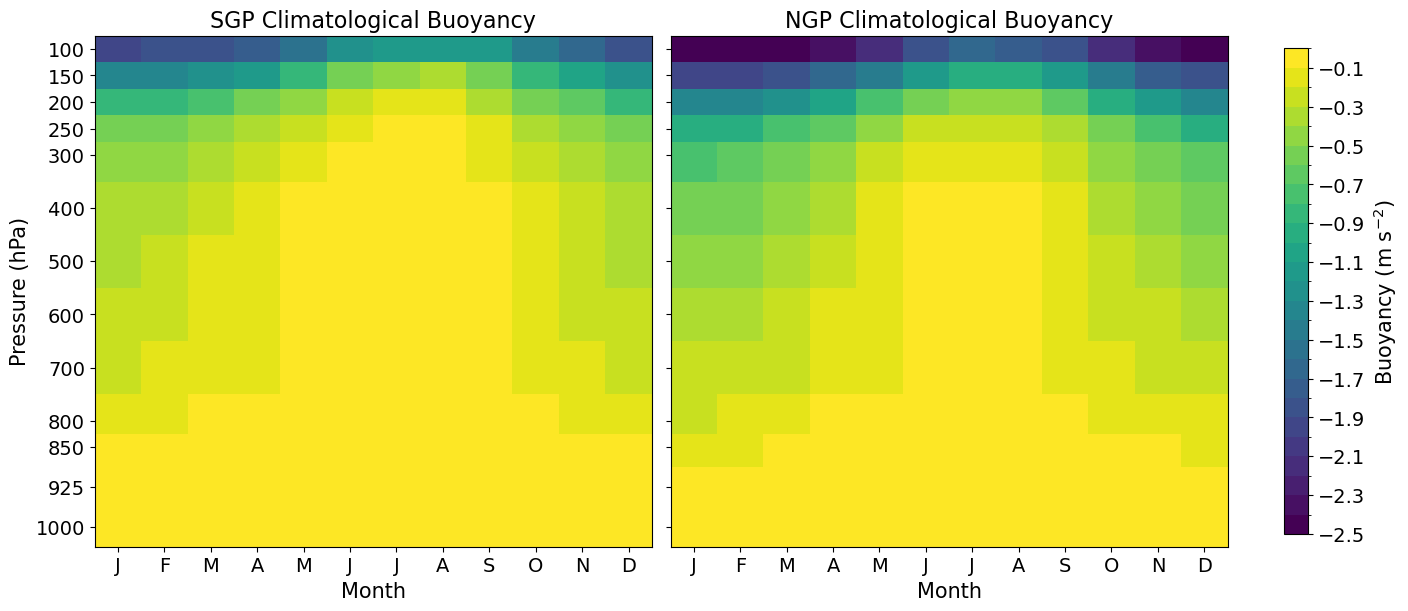

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl

# ============================================================
# STYLE
# ============================================================
mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 18
})

# ============================================================
# DATA & AXES SETUP
# ============================================================
months = np.arange(1, 13)
month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]
pressure = p_levels

# Use BOTH datasets for color limits
vmin = -2.5
vmax = 0

# ============================================================
# DISCRETE COLOR BINS
# ============================================================
bins = np.linspace(vmin, vmax, 26)   # 25 discrete bins

cmap = plt.get_cmap("viridis", len(bins) - 1)

norm = mcolors.BoundaryNorm(
    boundaries=bins,
    ncolors=cmap.N,
    clip=True
)
# Contour levels (independent of color bins)
levels = np.linspace(vmin, vmax, 9)

# ============================================================
# FIGURE
# ============================================================
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=True,
    constrained_layout=True
)

for ax, data, title in zip(
    axes,
    [sgp_monthly_c.values, ngp_monthly_c.values],
    ["SGP Climatological Buoyancy", "NGP Climatological Buoyancy"]
):

    pcm = ax.pcolormesh(
        month_edges,
        pressure_edges,
        data.T,          # (pressure, month)
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.set_xlabel("Month")
    ax.set_title(title)

    ax.set_yticks(pressure)
    ax.set_yticklabels(pressure.astype(int))
    ax.invert_yaxis()

axes[0].set_ylabel("Pressure (hPa)")

# ============================================================
# COLORBAR (SINGLE, DISCRETE)
# ============================================================
cbar = fig.colorbar(
    pcm,
    ax=axes,
    location="right",
    shrink=0.95,
    ticks=bins[::2]   # show every other bin label
)

cbar.set_label("Buoyancy (m s$^{-2}$)")

cbar_ticks = np.arange(vmin, vmax + 0.01, 0.5)

plt.gca().invert_yaxis()

plt.show()


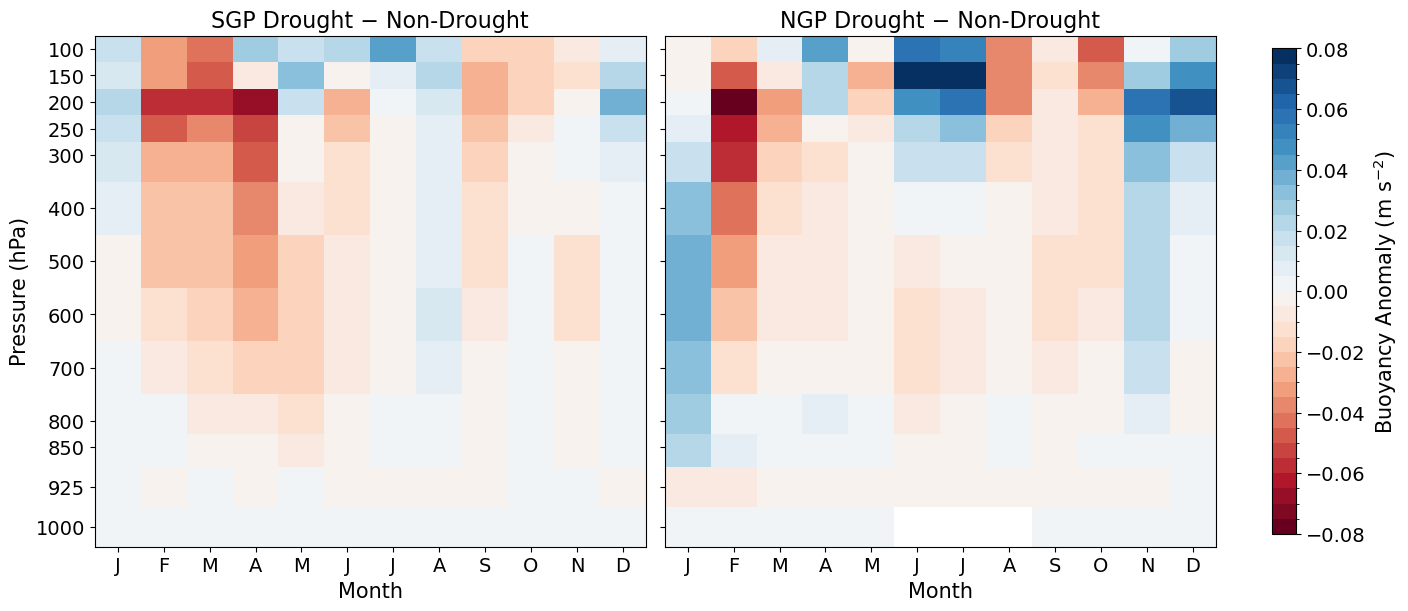

In [17]:
bins = np.linspace(-0.08, 0.08, 33)   # 32 color bins

cmap = plt.get_cmap("RdBu", len(bins) - 1)

norm = mcolors.BoundaryNorm(
    boundaries=bins,
    ncolors=cmap.N,
    clip=True
)


cbar_ticks = np.arange(-0.08, 0.081, 0.02)
# → [-0.08, -0.04, 0.00, 0.04, 0.08]

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=True,
    constrained_layout=True
)

for ax, data, title in zip(
    axes,
    [sgp_drought_anom.values, ngp_drought_anom.values],
    ["SGP Drought − Non-Drought", "NGP Drought − Non-Drought"]
):

    pcm = ax.pcolormesh(
        month_edges,
        pressure_edges,
        data.T,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.set_xlabel("Month")
    ax.set_title(title)

    ax.set_yticks(p_levels)
    ax.set_yticklabels(p_levels.astype(int))

    ax.invert_yaxis()
    
cbar = fig.colorbar(pcm, ax=axes, location="right", shrink=0.95, ticks=cbar_ticks)

cbar.set_label("Buoyancy Anomaly (m s$^{-2}$)")

axes[0].set_ylabel("Pressure (hPa)")

plt.gca().invert_yaxis()

plt.show()


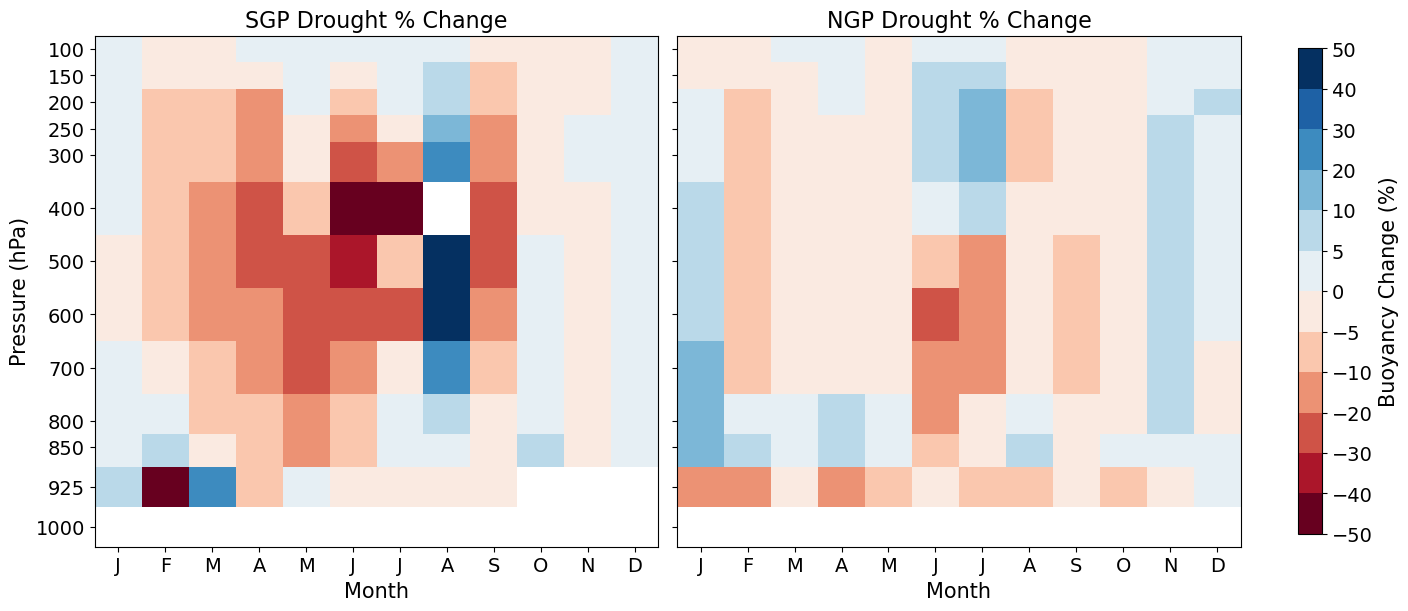

In [18]:
pct_max = 50

pct_vlim = max(pct_max, 5.0)

levels = np.linspace(-pct_vlim, pct_vlim, 10)

levels = levels[levels != 0]

bins = np.array([
    -50, -40, -30, -20, -10,
     -5,   0,
      5,  10,  20,  30,  40,  50
])

cmap = plt.get_cmap("RdBu", len(bins) - 1)

norm = mcolors.BoundaryNorm(
    
    boundaries=bins,
    
    ncolors=cmap.N,
    
    clip=True
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=True,
    constrained_layout=True
)

for ax, data, title in zip(
    axes,
    
    [sgp_drought_pct.values, ngp_drought_pct.values],
    
    ["SGP Drought % Change", "NGP Drought % Change"]
):

    pcm = ax.pcolormesh(
        
        month_edges,
        
        pressure_edges,
        
        data.T,
        
        cmap=cmap,
        
        norm=norm,
        
        shading="auto",
    )

    ax.set_xticks(months)
    
    ax.set_xticklabels(month_labels)
    
    ax.set_xlabel("Month")
    
    ax.set_title(title)
    
    ax.invert_yaxis()

axes[0].set_ylabel("Pressure (hPa)")

cbar = fig.colorbar(
    
    pcm,
    
    ax=axes,
    
    location="right",
    
    shrink=0.95,
    
    ticks=bins,
)

cbar.set_label("Buoyancy Change (%)")

ax.set_yticks(p_levels)

ax.set_yticklabels(p_levels.astype(int))

plt.gca().invert_yaxis()

plt.show()